# 05. 모델링

`04_eda`까지 생성한 파생변수 포함 데이터셋을 사용해 실거래가 예측 모델을 학습한다.

진행 순서:

- 최종 파생변수 데이터셋 로드 및 모델 학습용 컬럼 정리
- 시간 분할과 랜덤 분할 기준으로 기준 모델 성능 비교
- 가격대별 오차, log-price 실험, 변수 중요도, 예측값 비교를 통해 이후 모델 선정 근거 마련

In [ ]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT / 'src'))

os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(PROJECT_ROOT / '.cache'))
os.environ.setdefault('LOKY_MAX_CPU_COUNT', str(os.cpu_count() or 1))
(PROJECT_ROOT / '.matplotlib').mkdir(exist_ok=True)
(PROJECT_ROOT / '.cache').mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

DATA_PATH = PROJECT_ROOT / 'data/processed/seoul_apt_trade_2025_features.csv'
MODELING_DATA_PATH = PROJECT_ROOT / 'data/processed/modeling_dataset.csv'
SCORE_PATH = PROJECT_ROOT / 'reports/model_scores.csv'
PRICE_BAND_MAE_PATH = PROJECT_ROOT / 'reports/model_price_band_mae.csv'
PREDICTION_PATH = PROJECT_ROOT / 'reports/model_test_predictions.csv'
FIGURE_DIR = PROJECT_ROOT / 'reports/figures'
IMPORTANCE_PATH = FIGURE_DIR / 'model_feature_importance.png'

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 100)

## 1. 최종 파생변수 데이터 로드

모델링은 `03_feature_engineering`에서 만든 최종 데이터셋을 기준으로 한다.

In [271]:
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
print(f'rows: {len(df):,}')
print(f'columns: {len(df.columns):,}')
df.head()

rows: 77,359
columns: 31


,sigungu,apartment_name,area_m2,contract_ym,contract_day,price_10k_krw,floor,built_year,road_name,sido,gu,law_dong,contract_year,contract_month,contract_date,age,price_per_m2_10k_krw,full_road_address,geocode_status,matched_address,latitude,longitude,distance_to_cbd_km,distance_to_ybd_km,distance_to_gbd_km,nearest_business_district_distance_km,nearest_business_district,nearest_subway_distance_km,hospital_count_within_1km,nearest_hospital_distance_km,large_mart_count_within_1km
0,서울특별시 성동구 하왕십리동,왕십리KCC스위첸,64.236,202512,31,137500,8,2016,무학봉길 35,서울특별시,성동구,하왕십리동,2025,12,2025-12-31,9,2140.544243,서울특별시 성동구 무학봉길 35,ok,서울특별시 성동구 무학봉길 35 왕십리KCC스위첸,37.560960,127.026967,4.359801,10.131561,7.012161,4.359801,CBD,0.432088,1.0,0.470749,0.0
1,서울특별시 종로구 행촌동,대성아파트,94.940,202512,31,69500,3,1971,사직로 21,서울특별시,종로구,행촌동,2025,12,2025-12-31,54,732.041289,서울특별시 종로구 사직로 21,ok,서울특별시 종로구 사직로 21 대성아파트,37.572812,126.962566,1.530684,6.379895,10.112848,1.530684,CBD,0.467477,3.0,0.521502,0.0
2,서울특별시 중구 충무로4가,남산센트럴자이,82.413,202512,31,128000,18,2009,퇴계로 235,서울특별시,중구,충무로4가,2025,12,2025-12-31,16,1553.153022,서울특별시 중구 퇴계로 235,ok,서울특별시 중구 퇴계로 235 남산 센트럴 자이,37.562514,126.997824,1.802663,7.910221,7.649539,1.802663,CBD,0.352045,1.0,0.866817,0.0
3,서울특별시 성동구 마장동,현대,84.910,202512,31,118000,12,1998,살곶이길 50,서울특별시,성동구,마장동,2025,12,2025-12-31,27,1389.706748,서울특별시 성동구 살곶이길 50,ok,서울특별시 성동구 살곶이길 50 청계현대아파트,37.569933,127.042494,5.697082,11.785014,8.116617,5.697082,CBD,0.351577,0.0,1.151700,0.0
4,서울특별시 중구 충무로4가,남산센트럴자이,80.473,202512,31,125000,8,2009,퇴계로 235,서울특별시,중구,충무로4가,2025,12,2025-12-31,16,1553.316019,서울특별시 중구 퇴계로 235,ok,서울특별시 중구 퇴계로 235 남산 센트럴 자이,37.562514,126.997824,1.802663,7.910221,7.649539,1.802663,CBD,0.352045,1.0,0.866817,0.0


## 2. 모델 학습용 데이터셋 구성

좌표 생성, 주소 확인, 사후 검증용 컬럼은 모델 입력에서 제외한다. 타깃은 실거래가 총액인 `price_10k_krw`를 사용한다.

`price_per_m2_10k_krw`는 타깃인 거래가를 면적으로 나눈 값이라 누수 가능성이 있으므로 입력 변수에서 제외한다.

In [272]:
target_col = 'price_10k_krw'

numeric_features = [
    'area_m2',
    'floor',
    'built_year',
    'age',
    'contract_year',
    'contract_month',
    'contract_day',
    'distance_to_cbd_km',
    'distance_to_ybd_km',
    'distance_to_gbd_km',
    # 'nearest_business_district_distance_km',
    'nearest_subway_distance_km',
    # 'hospital_count_within_1km',
    'nearest_hospital_distance_km',
    'large_mart_count_within_1km',
]

categorical_features = [
    'gu',
    'law_dong',
    # 'apartment_name',
    # 'nearest_business_district',
]

required_columns = [target_col, 'contract_date', *numeric_features, *categorical_features]
modeling_df = df[required_columns].copy()
modeling_df['contract_date'] = pd.to_datetime(modeling_df['contract_date'])

missing_before = modeling_df.isna().sum().sort_values(ascending=False)
missing_before[missing_before > 0]

nearest_subway_distance_km      22
distance_to_ybd_km              22
distance_to_gbd_km              22
large_mart_count_within_1km     22
nearest_hospital_distance_km    22
distance_to_cbd_km              22
dtype: int64

In [273]:
rows_before = len(modeling_df)
modeling_df = modeling_df.dropna(subset=[target_col, *numeric_features, *categorical_features]).copy()
rows_after = len(modeling_df)

modeling_df.to_csv(MODELING_DATA_PATH, index=False, encoding='utf-8-sig')

print(f'모델링 데이터 저장: {MODELING_DATA_PATH}')
print(f'제거된 행: {rows_before - rows_after:,}')
print(f'최종 행 수: {rows_after:,}')
modeling_df.head()

모델링 데이터 저장: c:\Users\rwajm\Documents\GitHub\dm-apt-predict\data\processed\modeling_dataset.csv
제거된 행: 22
최종 행 수: 77,337


,price_10k_krw,contract_date,area_m2,floor,built_year,age,contract_year,contract_month,contract_day,distance_to_cbd_km,distance_to_ybd_km,distance_to_gbd_km,nearest_subway_distance_km,nearest_hospital_distance_km,large_mart_count_within_1km,gu,law_dong
0,137500,2025-12-31,64.236,8,2016,9,2025,12,31,4.359801,10.131561,7.012161,0.432088,0.470749,0.0,성동구,하왕십리동
1,69500,2025-12-31,94.940,3,1971,54,2025,12,31,1.530684,6.379895,10.112848,0.467477,0.521502,0.0,종로구,행촌동
2,128000,2025-12-31,82.413,18,2009,16,2025,12,31,1.802663,7.910221,7.649539,0.352045,0.866817,0.0,중구,충무로4가
3,118000,2025-12-31,84.910,12,1998,27,2025,12,31,5.697082,11.785014,8.116617,0.351577,1.151700,0.0,성동구,마장동
4,125000,2025-12-31,80.473,8,2009,16,2025,12,31,1.802663,7.910221,7.649539,0.352045,0.866817,0.0,중구,충무로4가


## 3. 학습/테스트 데이터 분할

실제 예측 상황과 비슷하게 거래일 기준 시간 분할을 사용한다. 2025년 1월부터 10월까지는 학습, 2025년 11월부터 12월까지는 테스트로 둔다.

In [274]:
split_date = pd.Timestamp('2025-11-01')
train_df = modeling_df[modeling_df['contract_date'] < split_date].copy()
test_df = modeling_df[modeling_df['contract_date'] >= split_date].copy()

X_train = train_df[numeric_features + categorical_features]
y_train = train_df[target_col]
X_test = test_df[numeric_features + categorical_features]
y_test = test_df[target_col]

split_summary = pd.DataFrame({
    'dataset': ['train', 'test'],
    'start_date': [train_df['contract_date'].min(), test_df['contract_date'].min()],
    'end_date': [train_df['contract_date'].max(), test_df['contract_date'].max()],
    'rows': [len(train_df), len(test_df)],
    'target_mean': [y_train.mean(), y_test.mean()],
    'target_median': [y_train.median(), y_test.median()],
})
split_summary

,dataset,start_date,end_date,rows,target_mean,target_median
0,train,2025-01-01,2025-10-31,69183,127969.020612,105000.0
1,test,2025-11-01,2025-12-31,8154,117914.702968,93000.0


## 4. 모델 파이프라인 정의

설치된 기본 라이브러리만 사용하기 위해 `scikit-learn` 모델로 기준선을 만든다.

- `DummyRegressor`: 평균값 예측 기준선
- `LinearRegression`: 선형회귀
- `RandomForestRegressor`: 랜덤 포레스트
- `ExtraTreesRegressor`: 엑스트라 트리
- `GradientBoostingRegressor`: 그래디언트 부스팅
- `HistGradientBoostingRegressor`: 히스토그램 기반 그래디언트 부스팅

In [275]:
onehot_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=20), categorical_features),
    ],
    remainder='drop',
)

ordinal_preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
        ]), categorical_features),
    ],
    remainder='drop',
)

models = {
    'dummy_mean': Pipeline([
        ('preprocess', ordinal_preprocessor),
        ('model', DummyRegressor(strategy='mean')),
    ]),
    'linear_regression': Pipeline([
        ('preprocess', onehot_preprocessor),
        ('model', LinearRegression()),
    ]),
    'random_forest': Pipeline([
        ('preprocess', ordinal_preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=120,
            max_depth=18,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1,
        )),
    ]),
    'extra_trees': Pipeline([
        ('preprocess', ordinal_preprocessor),
        ('model', ExtraTreesRegressor(
            n_estimators=120,
            max_depth=18,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1,
        )),
    ]),
    'gradient_boosting': Pipeline([
        ('preprocess', ordinal_preprocessor),
        ('model', GradientBoostingRegressor(
            n_estimators=160,
            learning_rate=0.06,
            max_depth=4,
            min_samples_leaf=3,
            random_state=42,
        )),
    ]),
    'hist_gradient_boosting': Pipeline([
        ('preprocess', ordinal_preprocessor),
        ('model', HistGradientBoostingRegressor(
            max_iter=250,
            learning_rate=0.06,
            max_leaf_nodes=31,
            l2_regularization=0.1,
            random_state=42,
        )),
    ]),
}

## 5. 모델 학습 및 평가

평가 지표는 회귀 문제에서 자주 쓰는 `MAE`, `RMSE`, `R2`를 사용한다. 금액 단위는 원본 타깃과 같은 만 원이다.

In [276]:
def evaluate_regression(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred),
    }


def fit_and_evaluate_models(X_train, y_train, X_test, y_test, split_strategy):
    scores = []
    fitted = {}

    for model_name, model in models.items():
        print(f'training: {split_strategy} / {model_name}')
        fitted_model = clone(model)
        fitted_model.fit(X_train, y_train)
        fitted[model_name] = fitted_model

        train_pred = fitted_model.predict(X_train)
        test_pred = fitted_model.predict(X_test)

        for dataset_name, y_true, y_pred in [
            ('train', y_train, train_pred),
            ('test', y_test, test_pred),
        ]:
            scores.append({
                'split_strategy': split_strategy,
                'model': model_name,
                'dataset': dataset_name,
                **evaluate_regression(y_true, y_pred),
            })

    return pd.DataFrame(scores), fitted


def make_test_prediction_df(fitted, X_test, y_test, split_strategy):
    rows = []
    for model_name, model in fitted.items():
        pred = model.predict(X_test)
        rows.append(pd.DataFrame({
            'split_strategy': split_strategy,
            'model': model_name,
            'actual_price_10k_krw': y_test.to_numpy(),
            'predicted_price_10k_krw': pred,
            'absolute_error_10k_krw': np.abs(y_test.to_numpy() - pred),
        }))
    return pd.concat(rows, ignore_index=True)

In [277]:
score_df, fitted_models = fit_and_evaluate_models(
    X_train,
    y_train,
    X_test,
    y_test,
    split_strategy='time_2025_01_10_train_11_12_test',
)

test_prediction_df = make_test_prediction_df(
    fitted_models,
    X_test,
    y_test,
    split_strategy='time_2025_01_10_train_11_12_test',
)

training: time_2025_01_10_train_11_12_test / dummy_mean
training: time_2025_01_10_train_11_12_test / linear_regression
training: time_2025_01_10_train_11_12_test / random_forest
training: time_2025_01_10_train_11_12_test / extra_trees
training: time_2025_01_10_train_11_12_test / gradient_boosting
training: time_2025_01_10_train_11_12_test / hist_gradient_boosting


In [278]:
score_df.to_csv(SCORE_PATH, index=False, encoding='utf-8-sig')
print(f'성능표 저장: {SCORE_PATH}')
score_df.sort_values(['split_strategy', 'dataset', 'rmse'])

성능표 저장: c:\Users\rwajm\Documents\GitHub\dm-apt-predict\reports\model_scores.csv


,split_strategy,model,dataset,mae,rmse,r2
7,time_2025_01_10_train_11_12_test,extra_trees,test,11293.889562,19185.049079,0.955903
5,time_2025_01_10_train_11_12_test,random_forest,test,11007.994379,20445.069462,0.949920
11,time_2025_01_10_train_11_12_test,hist_gradient_boosting,test,16269.139042,24826.686847,0.926154
9,time_2025_01_10_train_11_12_test,gradient_boosting,test,22144.587609,33035.770189,0.869246
3,time_2025_01_10_train_11_12_test,linear_regression,test,30143.743945,48822.442617,0.714421
1,time_2025_01_10_train_11_12_test,dummy_mean,test,63837.389029,91911.632707,-0.012111
6,time_2025_01_10_train_11_12_test,extra_trees,train,5805.128330,11705.516122,0.984874
4,time_2025_01_10_train_11_12_test,random_forest,train,5045.910380,12023.296058,0.984041
10,time_2025_01_10_train_11_12_test,hist_gradient_boosting,train,11971.446260,19468.332483,0.958158
8,time_2025_01_10_train_11_12_test,gradient_boosting,train,18143.519358,27220.155634,0.918204


## 6. 랜덤 80:20 분할 성능 비교

전체 데이터를 섞은 뒤 80%는 훈련셋, 20%는 테스트셋으로 사용한다. 시간 분할보다 일반적인 교차 검증 상황에 가까운 비교용 결과다.

In [279]:
X = modeling_df[numeric_features + categorical_features]
y = modeling_df[target_col]

X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

random_split_summary = pd.DataFrame({
    'dataset': ['train_random', 'test_random'],
    'rows': [len(X_train_random), len(X_test_random)],
    'target_mean': [y_train_random.mean(), y_test_random.mean()],
    'target_median': [y_train_random.median(), y_test_random.median()],
})
random_split_summary

,dataset,rows,target_mean,target_median
0,train_random,61869,127118.772439,104500.0
1,test_random,15468,126069.686385,104000.0


In [280]:
random_score_df, random_fitted_models = fit_and_evaluate_models(
    X_train_random,
    y_train_random,
    X_test_random,
    y_test_random,
    split_strategy='random_80_20',
)

random_prediction_df = make_test_prediction_df(
    random_fitted_models,
    X_test_random,
    y_test_random,
    split_strategy='random_80_20',
)
test_prediction_df = pd.concat([test_prediction_df, random_prediction_df], ignore_index=True)

score_df = pd.concat([score_df, random_score_df], ignore_index=True)
score_df.to_csv(SCORE_PATH, index=False, encoding='utf-8-sig')
print(f'성능표 업데이트: {SCORE_PATH}')
score_df.sort_values(['split_strategy', 'dataset', 'rmse'])

training: random_80_20 / dummy_mean


training: random_80_20 / linear_regression
training: random_80_20 / random_forest
training: random_80_20 / extra_trees
training: random_80_20 / gradient_boosting
training: random_80_20 / hist_gradient_boosting
성능표 업데이트: c:\Users\rwajm\Documents\GitHub\dm-apt-predict\reports\model_scores.csv


,split_strategy,model,dataset,mae,rmse,r2
19,random_80_20,extra_trees,test,8069.448329,16720.560917,0.966827
17,random_80_20,random_forest,test,7871.741360,17729.901854,0.962701
23,random_80_20,hist_gradient_boosting,test,13106.515790,21552.327952,0.944885
21,random_80_20,gradient_boosting,test,18827.977518,28727.263034,0.902080
15,random_80_20,linear_regression,test,26203.968227,42961.912461,0.780996
13,random_80_20,dummy_mean,test,61755.792805,91809.126740,-0.000131
16,random_80_20,random_forest,train,5186.206611,11936.050428,0.984402
18,random_80_20,extra_trees,train,5986.307206,12050.856078,0.984101
22,random_80_20,hist_gradient_boosting,train,12281.636693,20130.488954,0.955634
20,random_80_20,gradient_boosting,train,18296.185088,27365.801945,0.918010


## 7. 분할 방식별 테스트 성능 비교

시간 분할과 랜덤 분할 결과를 RMSE 기준으로 나란히 비교한다.

In [281]:
test_scores = score_df[score_df['dataset'].eq('test')].sort_values(['split_strategy', 'rmse']).reset_index(drop=True)
test_scores

,split_strategy,model,dataset,mae,rmse,r2
0,random_80_20,extra_trees,test,8069.448329,16720.560917,0.966827
1,random_80_20,random_forest,test,7871.741360,17729.901854,0.962701
2,random_80_20,hist_gradient_boosting,test,13106.515790,21552.327952,0.944885
3,random_80_20,gradient_boosting,test,18827.977518,28727.263034,0.902080
4,random_80_20,linear_regression,test,26203.968227,42961.912461,0.780996
5,random_80_20,dummy_mean,test,61755.792805,91809.126740,-0.000131
6,time_2025_01_10_train_11_12_test,extra_trees,test,11293.889562,19185.049079,0.955903
7,time_2025_01_10_train_11_12_test,random_forest,test,11007.994379,20445.069462,0.949920
8,time_2025_01_10_train_11_12_test,hist_gradient_boosting,test,16269.139042,24826.686847,0.926154
9,time_2025_01_10_train_11_12_test,gradient_boosting,test,22144.587609,33035.770189,0.869246


In [282]:
# Best model summary
time_best = test_scores[test_scores['split_strategy'].str.startswith('time')].iloc[0]
random_best = test_scores[test_scores['split_strategy'].str.startswith('random')].iloc[0]

print('=== Best Model (Time Split) ===')
print(f"  Model : {time_best['model']}")
print(f"  MAE   : {time_best['mae']:,.0f} 만원")
print(f"  RMSE  : {time_best['rmse']:,.0f} 만원")
print(f"  R²    : {time_best['r2']:.4f}")
print()
print('=== Best Model (Random Split, Reference) ===')
print(f"  Model : {random_best['model']}")
print(f"  MAE   : {random_best['mae']:,.0f} 만원")
print(f"  RMSE  : {random_best['rmse']:,.0f} 만원")
print(f"  R²    : {random_best['r2']:.4f}")

=== Best Model (Time Split) ===
  Model : extra_trees
  MAE   : 11,294 만원
  RMSE  : 19,185 만원
  R²    : 0.9559

=== Best Model (Random Split, Reference) ===
  Model : extra_trees
  MAE   : 8,069 만원
  RMSE  : 16,721 만원
  R²    : 0.9668


In [ ]:
# train vs test 성능 비교 (과적합 확인)
overfit_check = (
    score_df
    .pivot_table(
        index=['split_strategy', 'model'],
        columns='dataset',
        values=['mae', 'rmse', 'r2'],
    )
    .round(0)
)

split_order = [
    split for split in ['time_2025_01_10_train_11_12_test', 'random_80_20']
    if split in score_df['split_strategy'].unique()
]

fig, axes = plt.subplots(
    len(split_order),
    2,
    figsize=(14, 5 * len(split_order)),
    squeeze=False,
)

for row_idx, split_strategy in enumerate(split_order):
    split_scores = score_df[score_df['split_strategy'].eq(split_strategy)]
    for col_idx, metric in enumerate(['mae', 'rmse']):
        ax = axes[row_idx, col_idx]
        metric_scores = split_scores.pivot(index='model', columns='dataset', values=metric)
        model_order = [model_name for model_name in models.keys() if model_name in metric_scores.index]
        metric_scores = metric_scores.reindex(model_order)

        x = np.arange(len(metric_scores.index))
        width = 0.35
        ax.bar(x - width / 2, metric_scores['train'], width, label='train', color='#4C78A8', alpha=0.8)
        ax.bar(x + width / 2, metric_scores['test'], width, label='test', color='#F58518', alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(metric_scores.index, rotation=15, ha='right')
        ax.set_title(f'{metric.upper()} - Train vs Test ({split_strategy})')
        ax.set_ylabel(f'{metric.upper()} (10k KRW)')
        ax.legend()
        ax.grid(axis='y', alpha=0.25)

fig.tight_layout()
display(fig)
fig.savefig(PROJECT_ROOT / 'reports/figures/05_train_vs_test.png', dpi=150, bbox_inches='tight')
plt.close(fig)
overfit_check




In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = test_scores.sort_values(['split_strategy', 'rmse'], ascending=[True, False]).copy()
plot_df['label'] = plot_df['split_strategy'] + ' / ' + plot_df['model']
ax.barh(plot_df['label'], plot_df['rmse'], color='#4C78A8')
ax.set_xlabel('RMSE (10k KRW)')
ax.set_ylabel('split / model')
ax.set_title('Test RMSE by Split Strategy')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
display(fig)
plt.close(fig)

## 8. 가격대별 MAE 확인

전체 MAE만 보면 저가·고가 구간 중 어느 구간에서 오차가 큰지 알기 어렵다. 테스트셋의 실제 거래가를 가격 구간으로 나누고, 구간별 평균 절대 오차를 확인한다.

In [285]:
price_bins = [0, 50_000, 100_000, 150_000, 200_000, 300_000, np.inf]
price_labels = [
    '<=5eok',
    '5-10eok',
    '10-15eok',
    '15-20eok',
    '20-30eok',
    '>30eok',
]

test_prediction_df['price_band'] = pd.cut(
    test_prediction_df['actual_price_10k_krw'],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True,
)

price_band_mae = (
    test_prediction_df
    .groupby(['split_strategy', 'model', 'price_band'], observed=True)
    .agg(
        rows=('absolute_error_10k_krw', 'size'),
        actual_mean=('actual_price_10k_krw', 'mean'),
        pred_mean=('predicted_price_10k_krw', 'mean'),
        mae=('absolute_error_10k_krw', 'mean'),
    )
    .reset_index()
    .sort_values(['split_strategy', 'model', 'price_band'])
)

price_band_mae.to_csv(PRICE_BAND_MAE_PATH, index=False, encoding='utf-8-sig')
print(f'가격대별 MAE 저장: {PRICE_BAND_MAE_PATH}')
price_band_mae

가격대별 MAE 저장: c:\Users\rwajm\Documents\GitHub\dm-apt-predict\reports\model_price_band_mae.csv


,split_strategy,model,price_band,rows,actual_mean,pred_mean,mae
0,random_80_20,dummy_mean,<=5eok,1744,35192.733945,127118.772439,91926.038494
1,random_80_20,dummy_mean,5-10eok,5694,75472.984194,127118.772439,51645.788245
2,random_80_20,dummy_mean,10-15eok,4039,124213.884872,127118.772439,12615.193490
3,random_80_20,dummy_mean,15-20eok,2003,172643.778333,127118.772439,45525.005894
4,random_80_20,dummy_mean,20-30eok,1267,244744.859511,127118.772439,117626.087072
...,...,...,...,...,...,...,...
67,time_2025_01_10_train_11_12_test,random_forest,5-10eok,3420,74387.986842,74425.231953,6268.525209
68,time_2025_01_10_train_11_12_test,random_forest,10-15eok,1880,123836.756383,119167.328047,11938.530474
69,time_2025_01_10_train_11_12_test,random_forest,15-20eok,851,173651.964747,167496.912838,17202.254590
70,time_2025_01_10_train_11_12_test,random_forest,20-30eok,536,243921.007463,232204.308029,22942.482638


In [286]:
best_models = test_scores.groupby('split_strategy').first().reset_index()[['split_strategy', 'model']]
best_price_band_mae = price_band_mae.merge(best_models, on=['split_strategy', 'model'])
best_price_band_mae

,split_strategy,model,price_band,rows,actual_mean,pred_mean,mae
0,random_80_20,extra_trees,<=5eok,1744,35192.733945,38484.183213,4040.545858
1,random_80_20,extra_trees,5-10eok,5694,75472.984194,77955.946334,5213.763932
2,random_80_20,extra_trees,10-15eok,4039,124213.884872,124987.804583,7027.010263
3,random_80_20,extra_trees,15-20eok,2003,172643.778333,170739.971979,9223.846433
4,random_80_20,extra_trees,20-30eok,1267,244744.859511,240492.377628,15598.362194
5,random_80_20,extra_trees,>30eok,721,417932.736477,404786.008614,29769.430215
6,time_2025_01_10_train_11_12_test,extra_trees,<=5eok,1079,33663.158480,36367.615912,4149.128287
7,time_2025_01_10_train_11_12_test,extra_trees,5-10eok,3420,74387.986842,74659.528414,6047.819127
8,time_2025_01_10_train_11_12_test,extra_trees,10-15eok,1880,123836.756383,116928.552139,12582.844604
9,time_2025_01_10_train_11_12_test,extra_trees,15-20eok,851,173651.964747,162979.170602,19106.805904


In [ ]:
fig, axes = plt.subplots(1, len(best_models), figsize=(14, 4.5), sharey=True)
if len(best_models) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, best_models.iterrows()):
    plot_df = best_price_band_mae[
        best_price_band_mae['split_strategy'].eq(row['split_strategy'])
        & best_price_band_mae['model'].eq(row['model'])
    ]
    ax.bar(plot_df['price_band'].astype(str), plot_df['mae'], color='#4C78A8')
    ax.set_title(f"{row['split_strategy']} / {row['model']}")
    ax.set_xlabel('Actual price band')
    ax.tick_params(axis='x', rotation=35)
    ax.grid(axis='y', alpha=0.25)
axes[0].set_ylabel('MAE (10k KRW)')
fig.tight_layout()
display(fig)
plt.close(fig)

## 9. log-price 실험

`RandomForestRegressor`와 `ExtraTreesRegressor`를 기준으로 원가격을 직접 예측한 경우와 `log1p(price)`를 예측한 뒤 다시 가격 단위로 되돌린 경우를 비교한다. 이 실험은 최종 성능표에 저장하지 않고, log 변환이 실제로 도움이 되는지 확인하는 용도로만 사용한다.

In [288]:
def fit_log_price_model(base_model, X_train, y_train, X_test):
    log_model = clone(base_model)
    log_model.fit(X_train, np.log1p(y_train))
    log_pred = np.expm1(log_model.predict(X_test))
    return log_model, np.maximum(log_pred, 0)


def make_log_experiment(model_name, split_strategy, fitted_raw_model, X_train, y_train, X_test, y_test):
    raw_pred = fitted_raw_model.predict(X_test)
    _, log_pred = fit_log_price_model(models[model_name], X_train, y_train, X_test)

    rows = []
    prediction_frames = []
    for target_type, pred in [('raw_price', raw_pred), ('log_price', log_pred)]:
        rows.append({
            'model': model_name,
            'split_strategy': split_strategy,
            'target_type': target_type,
            **evaluate_regression(y_test, pred),
        })
        prediction_frames.append(pd.DataFrame({
            'model': model_name,
            'split_strategy': split_strategy,
            'target_type': target_type,
            'actual_price_10k_krw': y_test.to_numpy(),
            'predicted_price_10k_krw': pred,
            'absolute_error_10k_krw': np.abs(y_test.to_numpy() - pred),
        }))

    return pd.DataFrame(rows), pd.concat(prediction_frames, ignore_index=True)

In [289]:
log_experiment_parts = []
log_prediction_parts = []
log_experiment_model_names = ['random_forest', 'extra_trees']

for model_name in log_experiment_model_names:
    log_time_scores, log_time_predictions = make_log_experiment(
        model_name,
        'time_2025_01_10_train_11_12_test',
        fitted_models[model_name],
        X_train,
        y_train,
        X_test,
        y_test,
    )
    log_random_scores, log_random_predictions = make_log_experiment(
        model_name,
        'random_80_20',
        random_fitted_models[model_name],
        X_train_random,
        y_train_random,
        X_test_random,
        y_test_random,
    )
    log_experiment_parts.extend([log_time_scores, log_random_scores])
    log_prediction_parts.extend([log_time_predictions, log_random_predictions])

log_experiment_scores = pd.concat(log_experiment_parts, ignore_index=True)
log_experiment_predictions = pd.concat(log_prediction_parts, ignore_index=True)

In [290]:
log_experiment_scores.sort_values(['split_strategy', 'model', 'target_type'])

,model,split_strategy,target_type,mae,rmse,r2
7,extra_trees,random_80_20,log_price,8074.870327,17141.222451,0.965137
6,extra_trees,random_80_20,raw_price,8069.448329,16720.560917,0.966827
3,random_forest,random_80_20,log_price,7783.182835,18020.696481,0.961467
2,random_forest,random_80_20,raw_price,7871.741360,17729.901854,0.962701
5,extra_trees,time_2025_01_10_train_11_12_test,log_price,11442.789158,19517.850337,0.954359
4,extra_trees,time_2025_01_10_train_11_12_test,raw_price,11293.889562,19185.049079,0.955903
1,random_forest,time_2025_01_10_train_11_12_test,log_price,10915.711775,20557.476059,0.949368
0,random_forest,time_2025_01_10_train_11_12_test,raw_price,11007.994379,20445.069462,0.949920


In [291]:
log_experiment_predictions['price_band'] = pd.cut(
    log_experiment_predictions['actual_price_10k_krw'],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True,
)

log_price_band_mae = (
    log_experiment_predictions
    .groupby(['split_strategy', 'model', 'target_type', 'price_band'], observed=True)
    .agg(
        rows=('absolute_error_10k_krw', 'size'),
        actual_mean=('actual_price_10k_krw', 'mean'),
        pred_mean=('predicted_price_10k_krw', 'mean'),
        mae=('absolute_error_10k_krw', 'mean'),
    )
    .reset_index()
    .sort_values(['split_strategy', 'model', 'target_type', 'price_band'])
)

log_price_band_mae

,split_strategy,model,target_type,price_band,rows,actual_mean,pred_mean,mae
0,random_80_20,extra_trees,log_price,<=5eok,1744,35192.733945,37638.868063,3411.845712
1,random_80_20,extra_trees,log_price,5-10eok,5694,75472.984194,76923.756953,4765.619318
2,random_80_20,extra_trees,log_price,10-15eok,4039,124213.884872,123750.235139,7015.141448
3,random_80_20,extra_trees,log_price,15-20eok,2003,172643.778333,169228.449287,9545.663017
4,random_80_20,extra_trees,log_price,20-30eok,1267,244744.859511,237549.506833,16388.108724
5,random_80_20,extra_trees,log_price,>30eok,721,417932.736477,398422.009225,32730.299332
6,random_80_20,extra_trees,raw_price,<=5eok,1744,35192.733945,38484.183213,4040.545858
7,random_80_20,extra_trees,raw_price,5-10eok,5694,75472.984194,77955.946334,5213.763932
8,random_80_20,extra_trees,raw_price,10-15eok,4039,124213.884872,124987.804583,7027.010263
9,random_80_20,extra_trees,raw_price,15-20eok,2003,172643.778333,170739.971979,9223.846433


In [ ]:
fig, axes = plt.subplots(
    len(log_experiment_model_names),
    2,
    figsize=(14, 8),
    sharey=True,
)

split_strategies = log_experiment_scores['split_strategy'].unique()
for row_idx, model_name in enumerate(log_experiment_model_names):
    for col_idx, split_strategy in enumerate(split_strategies):
        ax = axes[row_idx, col_idx]
        plot_df = log_price_band_mae[
            log_price_band_mae['model'].eq(model_name)
            & log_price_band_mae['split_strategy'].eq(split_strategy)
        ]
        pivot_df = plot_df.pivot(index='price_band', columns='target_type', values='mae')
        x = np.arange(len(pivot_df.index))
        width = 0.38
        ax.bar(x - width / 2, pivot_df['raw_price'], width=width, label='raw_price', color='#4C78A8')
        ax.bar(x + width / 2, pivot_df['log_price'], width=width, label='log_price', color='#F58518')
        ax.set_title(f'{model_name} / {split_strategy}')
        ax.set_xticks(x)
        ax.set_xticklabels(pivot_df.index.astype(str), rotation=35, ha='right')
        ax.set_xlabel('Actual price band')
        ax.grid(axis='y', alpha=0.25)

axes[0, 0].set_ylabel('MAE (10k KRW)')
axes[1, 0].set_ylabel('MAE (10k KRW)')
axes[0, 0].legend()
fig.tight_layout()
display(fig)
plt.close(fig)

## 10. 변수 중요도 확인

`RandomForestRegressor`와 `ExtraTreesRegressor`의 변수 중요도를 함께 확인한다. 범주형 변수는 순서형 인코딩 기준으로 변수 단위 중요도를 해석한다.

In [293]:
importance_model_names = ['random_forest', 'extra_trees']
importance_frames = []

for model_name in importance_model_names:
    importance_model = fitted_models[model_name].named_steps['model']
    importance_frames.append(pd.DataFrame({
        'model': model_name,
        'feature': numeric_features + categorical_features,
        'importance': importance_model.feature_importances_,
    }))

importance_df = (
    pd.concat(importance_frames, ignore_index=True)
    .sort_values(['model', 'importance'], ascending=[True, False])
)

importance_df.to_csv(PROJECT_ROOT / 'reports/model_feature_importance.csv', index=False, encoding='utf-8-sig')
importance_df

,model,feature,importance
24,extra_trees,distance_to_gbd_km,0.325026
15,extra_trees,area_m2,0.272794
17,extra_trees,built_year,0.069125
28,extra_trees,gu,0.068343
18,extra_trees,age,0.061392
23,extra_trees,distance_to_ybd_km,0.049206
22,extra_trees,distance_to_cbd_km,0.044976
27,extra_trees,large_mart_count_within_1km,0.028864
29,extra_trees,law_dong,0.027748
26,extra_trees,nearest_hospital_distance_km,0.020036


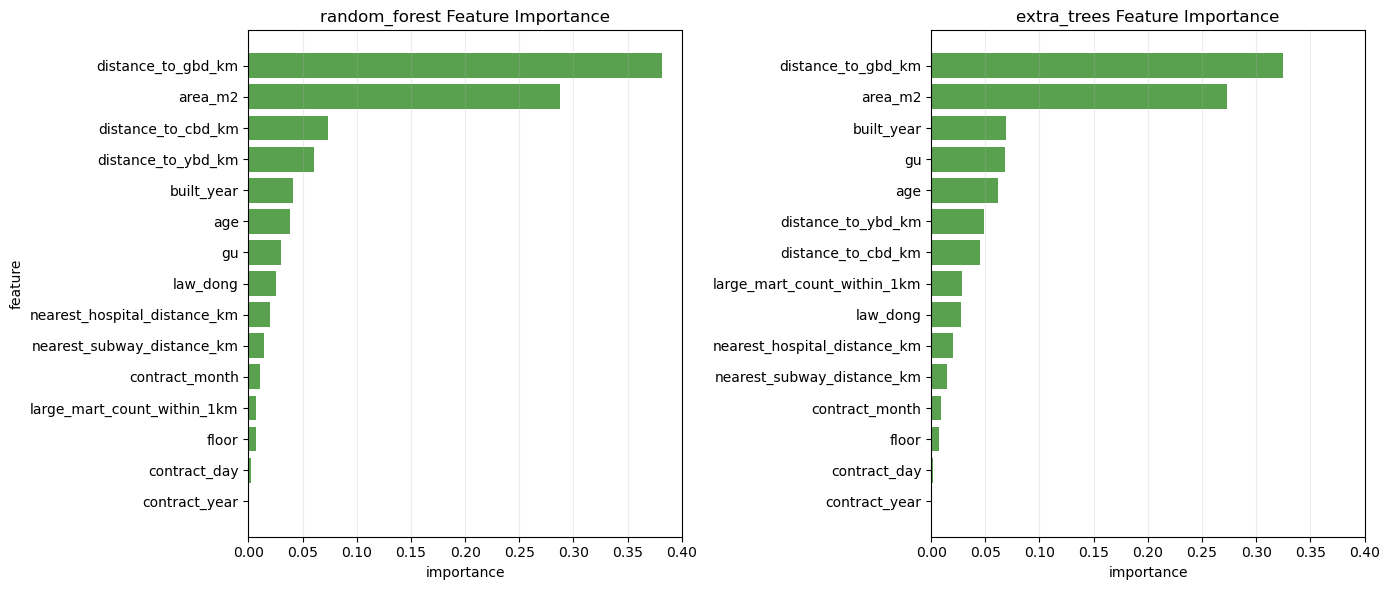

변수 중요도 그림 저장: c:\Users\rwajm\Documents\GitHub\dm-apt-predict\reports\figures\model_feature_importance.png


In [294]:
fig, axes = plt.subplots(1, len(importance_model_names), figsize=(14, 6), sharex=True)
if len(importance_model_names) == 1:
    axes = [axes]

for ax, model_name in zip(axes, importance_model_names):
    top_importance = (
        importance_df[importance_df['model'].eq(model_name)]
        .head(20)
        .sort_values('importance')
    )
    ax.barh(top_importance['feature'], top_importance['importance'], color='#59A14F')
    ax.set_xlabel('importance')
    ax.set_title(f'{model_name} Feature Importance')
    ax.grid(axis='x', alpha=0.25)

axes[0].set_ylabel('feature')
fig.tight_layout()
display(fig)
fig.savefig(IMPORTANCE_PATH, dpi=150, bbox_inches='tight')
print(f'변수 중요도 그림 저장: {IMPORTANCE_PATH}')
plt.close(fig)

## 11. RandomForest와 ExtraTrees 예측 확인

테스트셋에 대해 `RandomForest`와 `ExtraTrees`가 예측한 가격을 실제 거래가와 나란히 비교한다. 가격 단위는 원본과 같은 만 원이며, 해석을 쉽게 하기 위해 억 원 단위 컬럼도 함께 만든다.

In [295]:
prediction_model_names = ['random_forest', 'extra_trees']
prediction_info_cols = [
    'contract_date',
    'gu',
    'law_dong',
    'apartment_name',
    'area_m2',
    'floor',
    'built_year',
    'age',
]


def make_prediction_comparison(fitted, X_data, y_data, source_df, split_strategy):
    available_info_cols = [col for col in prediction_info_cols if col in source_df.columns]
    prediction_df = source_df.loc[X_data.index, available_info_cols].copy()
    prediction_df.insert(0, 'split_strategy', split_strategy)
    prediction_df['actual_price_10k_krw'] = y_data.to_numpy()
    prediction_df['actual_price_eok'] = prediction_df['actual_price_10k_krw'] / 10_000

    for model_name in prediction_model_names:
        pred = fitted[model_name].predict(X_data)
        prediction_df[f'{model_name}_pred_price_10k_krw'] = pred
        prediction_df[f'{model_name}_pred_price_eok'] = pred / 10_000
        prediction_df[f'{model_name}_abs_error_10k_krw'] = np.abs(y_data.to_numpy() - pred)
        prediction_df[f'{model_name}_abs_error_eok'] = prediction_df[f'{model_name}_abs_error_10k_krw'] / 10_000

    return prediction_df


time_prediction_comparison = make_prediction_comparison(
    fitted_models,
    X_test,
    y_test,
    modeling_df,
    'time_2025_01_10_train_11_12_test',
)

random_prediction_comparison = make_prediction_comparison(
    random_fitted_models,
    X_test_random,
    y_test_random,
    modeling_df,
    'random_80_20',
)

prediction_comparison = pd.concat(
    [time_prediction_comparison, random_prediction_comparison],
    ignore_index=True,
)

prediction_comparison.to_csv(PREDICTION_PATH, index=False, encoding='utf-8-sig')
print(f'예측 결과 저장: {PREDICTION_PATH}')
prediction_comparison.head()

예측 결과 저장: c:\Users\rwajm\Documents\GitHub\dm-apt-predict\reports\model_test_predictions.csv


,split_strategy,contract_date,gu,law_dong,area_m2,floor,built_year,age,actual_price_10k_krw,actual_price_eok,random_forest_pred_price_10k_krw,random_forest_pred_price_eok,random_forest_abs_error_10k_krw,random_forest_abs_error_eok,extra_trees_pred_price_10k_krw,extra_trees_pred_price_eok,extra_trees_abs_error_10k_krw,extra_trees_abs_error_eok
0,time_2025_01_10_train_11_12_test,2025-12-31,성동구,하왕십리동,64.236,8,2016,9,137500,13.75,128307.674869,12.830767,9192.325131,0.919233,130104.108431,13.010411,7395.891569,0.739589
1,time_2025_01_10_train_11_12_test,2025-12-31,종로구,행촌동,94.940,3,1971,54,69500,6.95,82374.151069,8.237415,12874.151069,1.287415,79784.977007,7.978498,10284.977007,1.028498
2,time_2025_01_10_train_11_12_test,2025-12-31,중구,충무로4가,82.413,18,2009,16,128000,12.80,110870.794696,11.087079,17129.205304,1.712921,112459.189667,11.245919,15540.810333,1.554081
3,time_2025_01_10_train_11_12_test,2025-12-31,성동구,마장동,84.910,12,1998,27,118000,11.80,109906.013164,10.990601,8093.986836,0.809399,109068.150193,10.906815,8931.849807,0.893185
4,time_2025_01_10_train_11_12_test,2025-12-31,중구,충무로4가,80.473,8,2009,16,125000,12.50,107043.158556,10.704316,17956.841444,1.795684,106250.274001,10.625027,18749.725999,1.874973


In [296]:
prediction_summary = []
for split_strategy, group in prediction_comparison.groupby('split_strategy'):
    for model_name in prediction_model_names:
        prediction_summary.append({
            'split_strategy': split_strategy,
            'model': model_name,
            'mean_abs_error_10k_krw': group[f'{model_name}_abs_error_10k_krw'].mean(),
            'median_abs_error_10k_krw': group[f'{model_name}_abs_error_10k_krw'].median(),
            'mean_abs_error_eok': group[f'{model_name}_abs_error_eok'].mean(),
            'median_abs_error_eok': group[f'{model_name}_abs_error_eok'].median(),
        })

prediction_summary_df = pd.DataFrame(prediction_summary)
prediction_summary_df.sort_values(['split_strategy', 'mean_abs_error_10k_krw'])

,split_strategy,model,mean_abs_error_10k_krw,median_abs_error_10k_krw,mean_abs_error_eok,median_abs_error_eok
0,random_80_20,random_forest,7871.741360,3662.657258,0.787174,0.366266
1,random_80_20,extra_trees,8069.448329,4034.885127,0.806945,0.403489
2,time_2025_01_10_train_11_12_test,random_forest,11007.994379,5863.077838,1.100799,0.586308
3,time_2025_01_10_train_11_12_test,extra_trees,11293.889562,6323.547905,1.129389,0.632355


In [297]:
display_cols = [
    'split_strategy',
    'contract_date',
    'gu',
    'law_dong',
    'apartment_name',
    'area_m2',
    'floor',
    'actual_price_10k_krw',
    'actual_price_eok',
    'random_forest_pred_price_eok',
    'random_forest_abs_error_eok',
    'extra_trees_pred_price_eok',
    'extra_trees_abs_error_eok',
]

available_display_cols = [col for col in display_cols if col in prediction_comparison.columns]
prediction_comparison[available_display_cols].sample(10, random_state=42).sort_values('split_strategy')

,split_strategy,contract_date,gu,law_dong,area_m2,floor,actual_price_10k_krw,actual_price_eok,random_forest_pred_price_eok,random_forest_abs_error_eok,extra_trees_pred_price_eok,extra_trees_abs_error_eok
22281,random_80_20,2025-06-19,송파구,송파동,106.8873,2,182300,18.230,18.929609,0.699609,19.422557,1.192557
20879,random_80_20,2025-11-29,용산구,용문동,59.9400,9,134000,13.400,13.868972,0.468972,13.563318,0.163318
13574,random_80_20,2025-08-27,노원구,상계동,84.9990,8,104500,10.450,10.562034,0.112034,10.435875,0.014125
8743,random_80_20,2025-02-28,강서구,등촌동,41.8500,7,56900,5.690,5.827632,0.137632,5.836545,0.146545
12527,random_80_20,2025-02-17,영등포구,신길동,42.6800,23,80000,8.000,8.773608,0.773608,8.833742,0.833742
5496,time_2025_01_10_train_11_12_test,2025-11-26,강서구,등촌동,80.6400,13,93250,9.325,8.835814,0.489186,9.097510,0.227490
3398,time_2025_01_10_train_11_12_test,2025-12-09,노원구,공릉동,49.5000,11,50500,5.050,4.984608,0.065392,4.892339,0.157661
7917,time_2025_01_10_train_11_12_test,2025-11-03,서초구,서초동,68.2100,18,103000,10.300,9.036973,1.263027,10.474179,0.174179
5227,time_2025_01_10_train_11_12_test,2025-11-28,관악구,신림동,59.9900,2,60000,6.000,5.712847,0.287153,5.655625,0.344375
7997,time_2025_01_10_train_11_12_test,2025-11-03,양천구,신월동,59.4900,12,70500,7.050,6.594229,0.455771,6.654400,0.395600


### 가격대별 평균 잔차

가격 구간별로 예측값과 실제값의 평균 잔차(예측가 - 실제가)를 비교한다. 0 기준선 위쪽은 과대 예측, 아래쪽은 과소 예측이다.

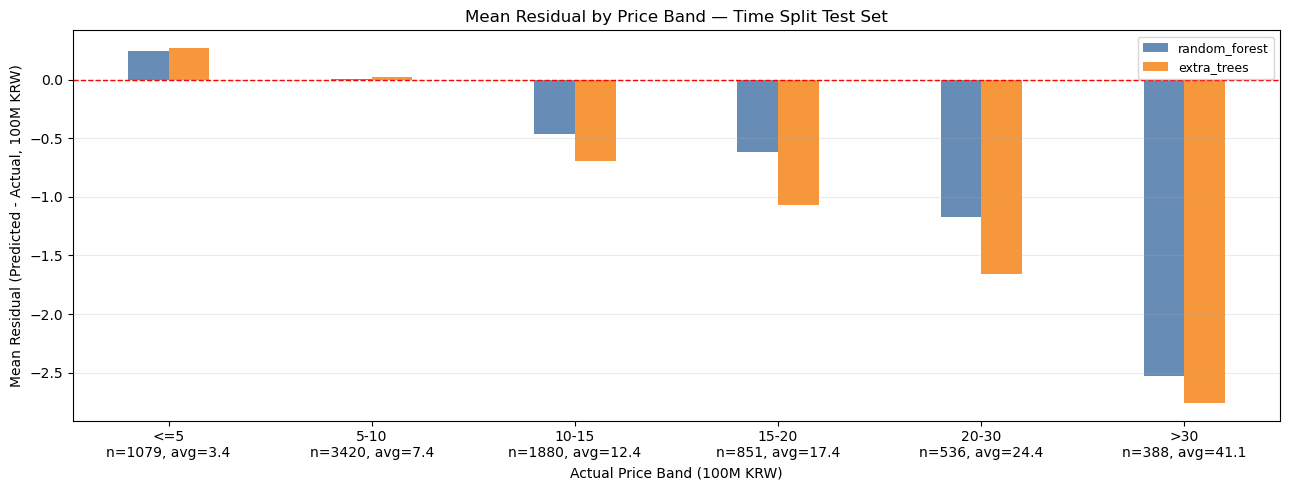

In [298]:
time_comparison = prediction_comparison[
    prediction_comparison['split_strategy'].str.startswith('time')
].copy()

time_comparison['price_band'] = pd.cut(
    time_comparison['actual_price_eok'],
    bins=[0, 5, 10, 15, 20, 30, float('inf')],
    labels=['<=5', '5-10', '10-15', '15-20', '20-30', '>30'],
    include_lowest=True,
)

colors = {
    'random_forest': '#4C78A8',
    'extra_trees': '#F58518',
}

price_bands = ['<=5', '5-10', '10-15', '15-20', '20-30', '>30']

residual_rows = []
for model_name in prediction_model_names:
    time_comparison[f'{model_name}_residual_eok'] = (
        time_comparison[f'{model_name}_pred_price_eok'] - time_comparison['actual_price_eok']
    )
    band_mean = time_comparison.groupby('price_band', observed=True)[f'{model_name}_residual_eok'].mean()
    for band, val in band_mean.items():
        residual_rows.append({'price_band': band, 'model': model_name, 'mean_residual': val})

residual_df = pd.DataFrame(residual_rows)
band_counts = time_comparison.groupby('price_band', observed=True).size().reindex(price_bands)
band_actual_mean = time_comparison.groupby('price_band', observed=True)['actual_price_eok'].mean().reindex(price_bands)

n_models = len(prediction_model_names)
x = range(len(price_bands))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 5))

for idx, model_name in enumerate(prediction_model_names):
    vals = residual_df[residual_df['model'] == model_name].set_index('price_band').reindex(price_bands)['mean_residual']
    offset = (idx - (n_models - 1) / 2) * width
    ax.bar([v + offset for v in x], vals.values, width, label=model_name, color=colors[model_name], alpha=0.85)

ax.axhline(0, color='red', linewidth=1, linestyle='--')
ax.set_xticks(list(x))
ax.set_xticklabels([
    f'{b}\nn={int(cnt)}, avg={avg:.1f}'
    for b, cnt, avg in zip(price_bands, band_counts.values, band_actual_mean.values)
])
ax.set_xlabel('Actual Price Band (100M KRW)')
ax.set_ylabel('Mean Residual (Predicted - Actual, 100M KRW)')
ax.set_title('Mean Residual by Price Band — Time Split Test Set')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.25)

fig.tight_layout()
display(fig)
fig.savefig(PROJECT_ROOT / 'reports/figures/05_residual_by_price_band.png', dpi=150, bbox_inches='tight')
plt.close(fig)


In [299]:
def predict_apartment_price(feature_row, fitted, model_names=prediction_model_names, actual_target=None):
    if isinstance(feature_row, dict):
        input_df = pd.DataFrame([feature_row])
    else:
        input_df = feature_row.copy()

    input_df = input_df[numeric_features + categorical_features]
    result = pd.DataFrame(index=input_df.index)
    if actual_target is not None:
        if isinstance(actual_target, pd.Series):
            actual_values = actual_target.reindex(input_df.index).to_numpy()
        else:
            actual_values = np.asarray(actual_target)
        result['actual_price_10k_krw'] = actual_values
        result['actual_price_eok'] = result['actual_price_10k_krw'] / 10_000
    for model_name in model_names:
        pred = fitted[model_name].predict(input_df)
        result[f'{model_name}_pred_price_10k_krw'] = pred
        result[f'{model_name}_pred_price_eok'] = pred / 10_000
    return result

# 아래 예시는 시간 분할 테스트셋의 첫 번째 행을 사용한다.
# 직접 예측해보고 싶으면 example_features의 값을 수정한 뒤 이 셀을 다시 실행한다.
example_features = X_test.iloc[[0]].copy()
predict_apartment_price(example_features, fitted_models, actual_target=y_test)

,actual_price_10k_krw,actual_price_eok,random_forest_pred_price_10k_krw,random_forest_pred_price_eok,extra_trees_pred_price_10k_krw,extra_trees_pred_price_eok
0,137500,13.75,128307.674869,12.830767,130104.108431,13.010411


## 12. 진행사항 정리 및 다음 단계

현재 노트북은 기준 모델 성능 비교까지 수행한다. 이 노트북의 테스트셋 결과는 후보 모델 탐색 목적이며, 최종 모델 선정은 이후 단계에서 검증셋 기준으로 진행한다.

이후 변수 조합 비교, 하이퍼파라미터 튜닝, 최종 모델 확정을 진행한다.